In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [12]:
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')
print('Train Shape:', train_df.shape)
print('Test Shape:', test_df.shape)

Train Shape: (100000, 28)
Test Shape: (50000, 27)


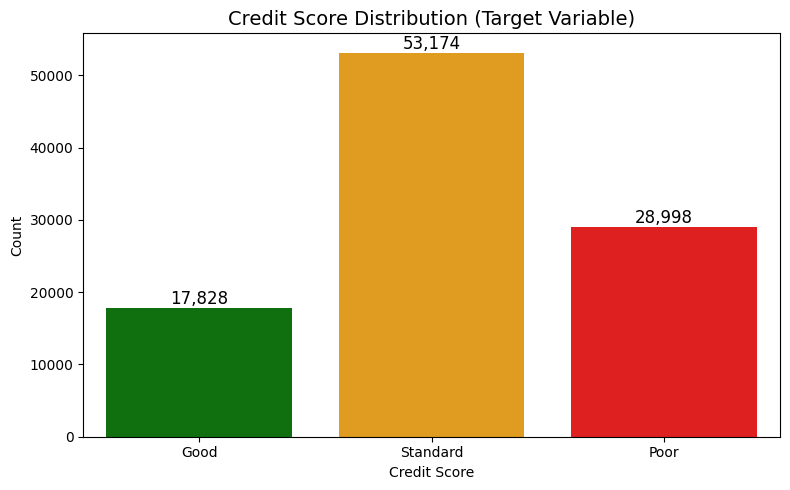


Class Distribution %:
Credit_Score
Standard    53.17%
Poor         29.0%
Good        17.83%
Name: proportion, dtype: str


In [13]:
# Class distribution
plt.figure(figsize=(8,5))
ax = sns.countplot(data=train_df, x='Credit_Score', 
                   order=['Good', 'Standard', 'Poor'],
                   palette=['green', 'orange', 'red'])

# Add counts on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.title('Credit Score Distribution (Target Variable)', fontsize=14)
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Percentage
print("\nClass Distribution %:")
print(train_df['Credit_Score'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

In [14]:
# Observations :
# Class imbalance exists! We'll handle this in preprocessing with class weights or SMOTE.

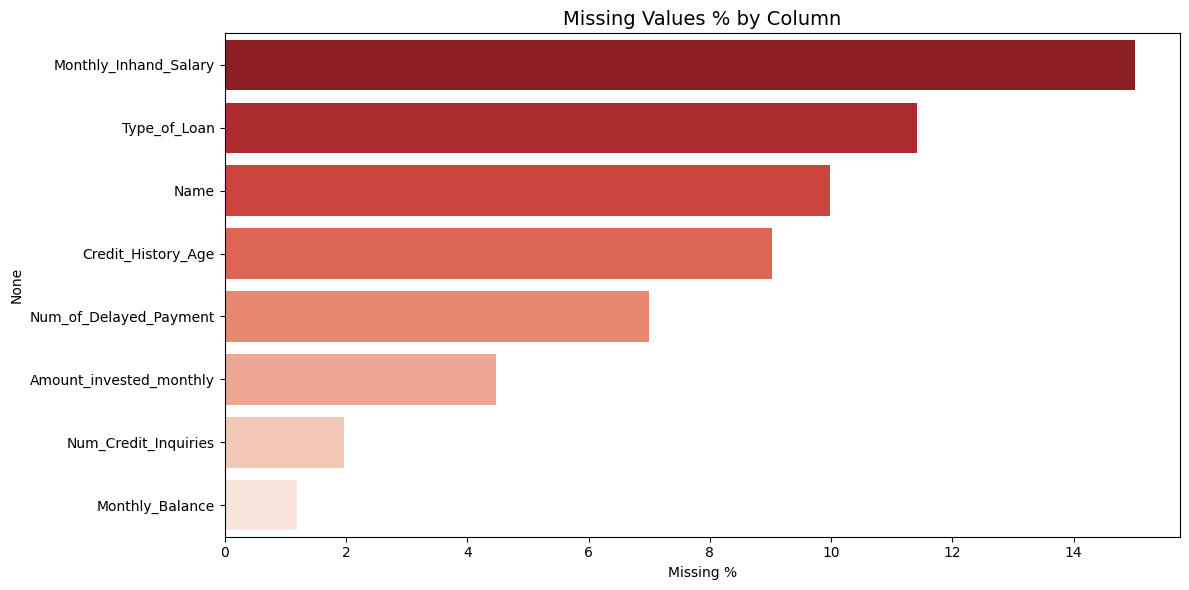


Missing Value %:
Monthly_Inhand_Salary       15.0%
Type_of_Loan               11.41%
Name                        9.98%
Credit_History_Age          9.03%
Num_of_Delayed_Payment       7.0%
Amount_invested_monthly     4.48%
Num_Credit_Inquiries        1.96%
Monthly_Balance              1.2%
dtype: str


In [15]:
# Null value heatmap
plt.figure(figsize=(12,6))
null_pct = (train_df.isnull().mean() * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

sns.barplot(x=null_pct.values, y=null_pct.index, palette='Reds_r')
plt.title('Missing Values % by Column', fontsize=14)
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

print("\nMissing Value %:")
print(null_pct.round(2).astype(str) + '%')

In [16]:
# Monthly_Inhand_Salary    15%  ← fill with median
# Type_of_Loan             11%  ← fill with 'Unknown'
# Name                     10%  ← drop column (not useful for ML)
# Credit_History_Age        9%  ← fill with median
# Num_of_Delayed_Payment    7%  ← fill with median
# Amount_invested_monthly   4%  ← fill with median
# Num_Credit_Inquiries      2%  ← fill with median
# Monthly_Balance           1%  ← fill with median

# No column exceeds 20% nulls — all recoverable! 

Numeric columns: ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']


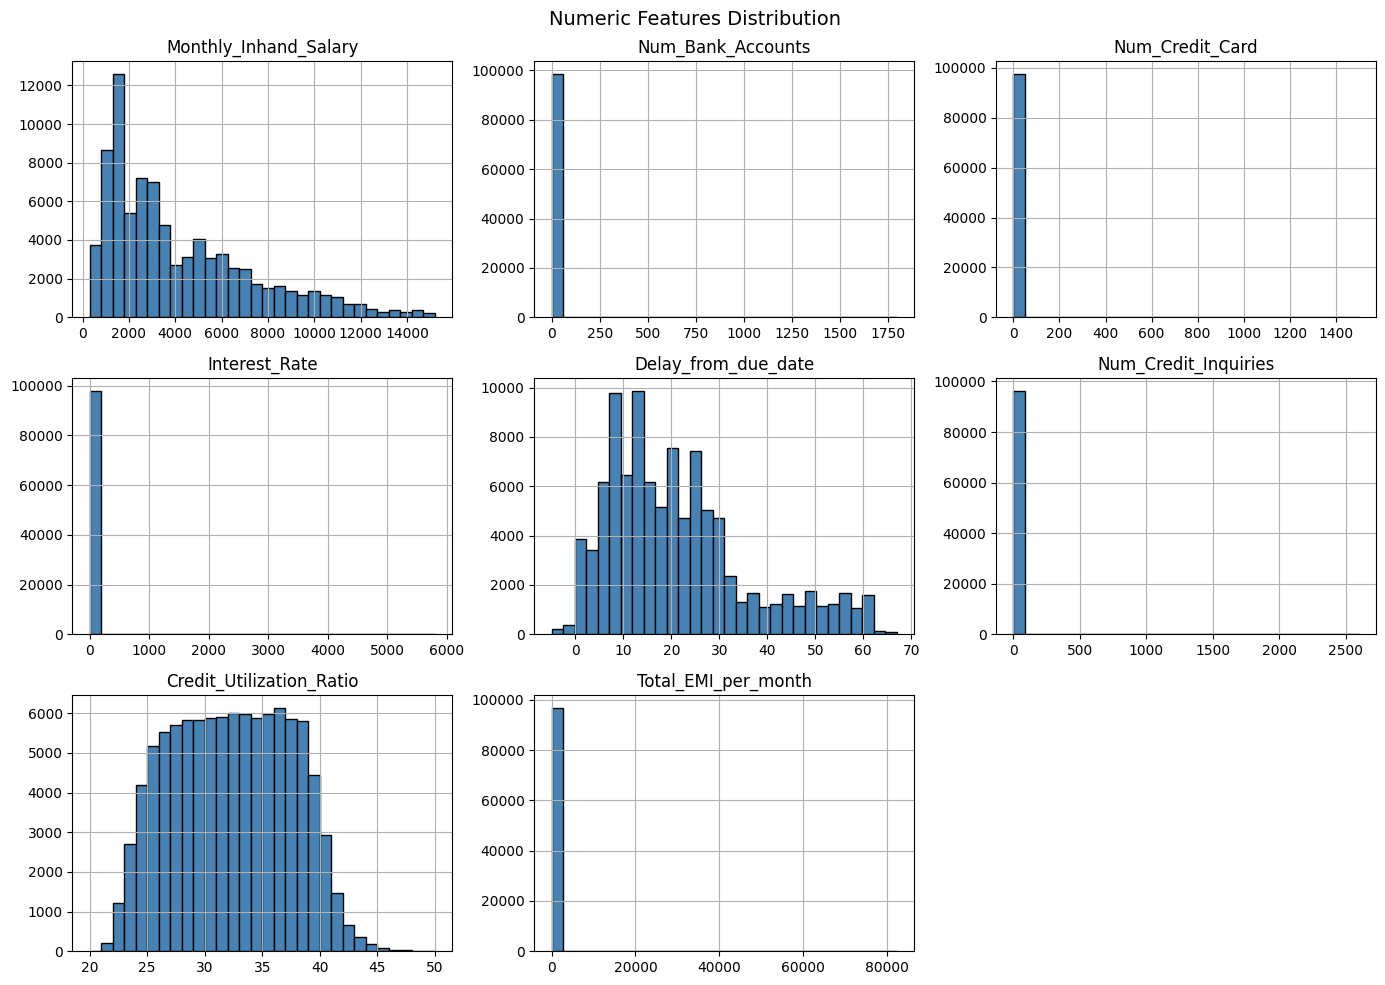

In [17]:
# Numeric Features Distribution
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

train_df[numeric_cols].hist(figsize=(14,10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Numeric Features Distribution', fontsize=14)
plt.tight_layout()
plt.show()

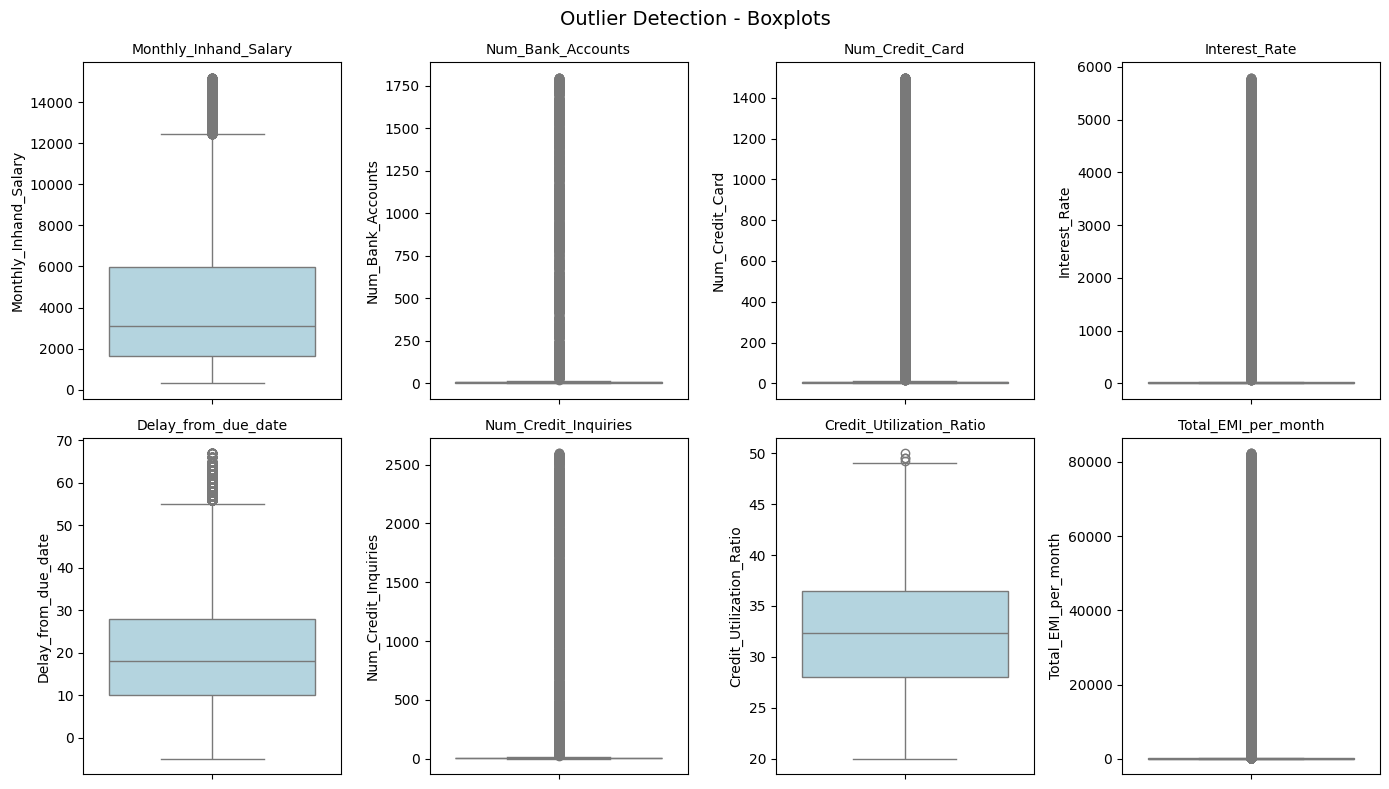

In [20]:
# Outlier Detection
plt.figure(figsize=(14,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=train_df[col], color='lightblue')
    plt.title(col, fontsize=10)
plt.suptitle('Outlier Detection - Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# Distribution Analysis:
# Monthly_Inhand_Salary  → Right skewed — most earn low, few earn high
# Num_Bank_Accounts      → Heavy outliers (values up to 1750!) — dirty data
# Num_Credit_Card        → Heavy outliers (values up to 1400!) — dirty data
# Interest_Rate          → Heavy outliers (values up to 6000!) — dirty data
# Delay_from_due_date    → Slightly right skewed — normal
# Num_Credit_Inquiries   → Heavy outliers (up to 2500!) — dirty data
# Credit_Utilization     → Normal distribution ✅
# Total_EMI_per_month    → Heavy outliers (up to 80000!) — dirty data

# Key Findings:

# Extreme outliers in Num_Bank_Accounts, Num_Credit_Card, Interest_Rate, Num_Credit_Inquiries, Total_EMI_per_month — these are clearly data entry errors
# Credit_Utilization_Ratio looks clean ✅
# Delay_from_due_date looks reasonable ✅

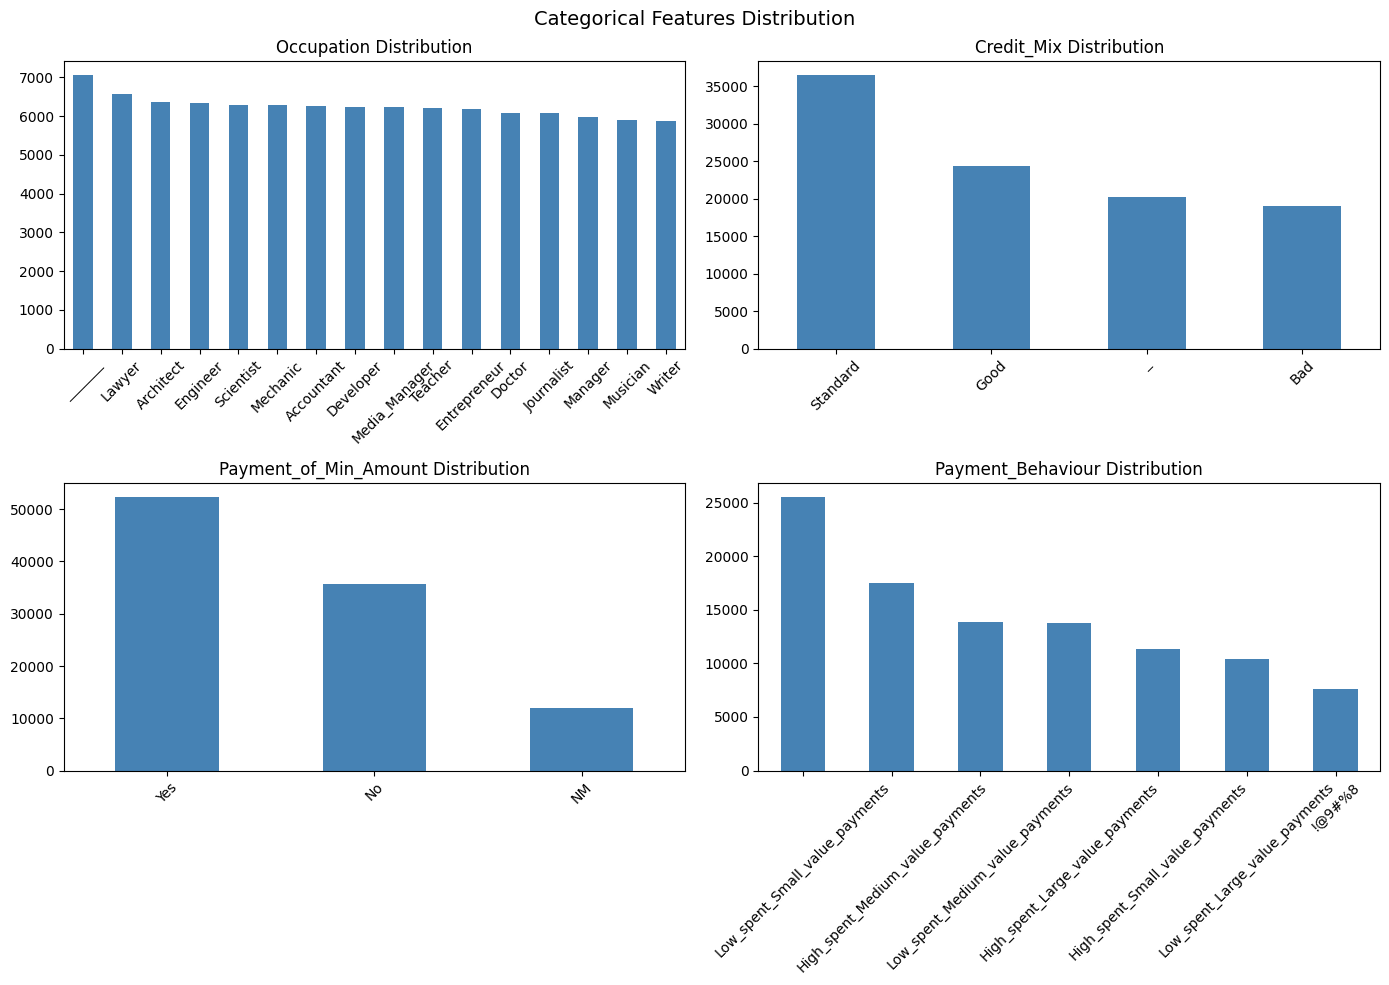

In [21]:
# Categorical Features Analysis
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    train_df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features Distribution', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Observations 🔍
# Occupation:

# Evenly distributed across all occupations ✅
# One category is / — dirty data! needs cleaning

# Credit_Mix:

# Has - category — dirty data! needs to be treated as null
# Standard > Good > Bad distribution

# Payment_of_Min_Amount:

# Has NM category — dirty data! needs cleaning
# Yes > No > NM

# Payment_Behaviour:

# Has !@9#%8 category — dirty data! needs cleaning
# Otherwise well distributed ✅

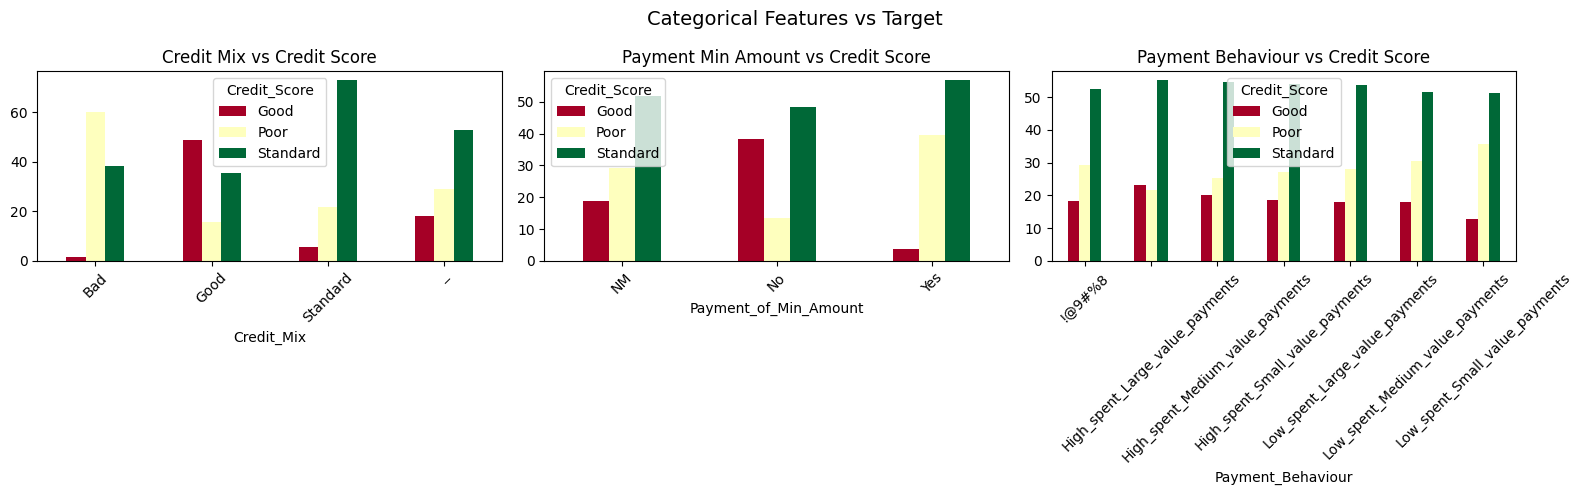

In [22]:
# Feature vs Target Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Credit Mix vs Credit Score
ct1 = pd.crosstab(train_df['Credit_Mix'], train_df['Credit_Score'], normalize='index') * 100
ct1.plot(kind='bar', ax=axes[0], colormap='RdYlGn')
axes[0].set_title('Credit Mix vs Credit Score')
axes[0].tick_params(axis='x', rotation=45)

# Payment_of_Min_Amount vs Credit Score
ct2 = pd.crosstab(train_df['Payment_of_Min_Amount'], train_df['Credit_Score'], normalize='index') * 100
ct2.plot(kind='bar', ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Payment Min Amount vs Credit Score')
axes[1].tick_params(axis='x', rotation=45)

# Payment_Behaviour vs Credit Score
ct3 = pd.crosstab(train_df['Payment_Behaviour'], train_df['Credit_Score'], normalize='index') * 100
ct3.plot(kind='bar', ax=axes[2], colormap='RdYlGn')
axes[2].set_title('Payment Behaviour vs Credit Score')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Target', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Observations 🔍
# Credit Mix vs Credit Score:

# Good credit mix → mostly Good credit score ✅
# Bad credit mix → mostly Poor credit score ✅
# Strong predictor! 🎯

# Payment of Min Amount vs Credit Score:

# Yes → mostly Standard/Good ✅
# No → mostly Poor ✅
# Strong predictor! 🎯

# Payment Behaviour vs Credit Score:

# !@9#%8 → dirty data, needs cleaning
# Otherwise fairly evenly distributed across behaviours
# Weak predictor compared to above two

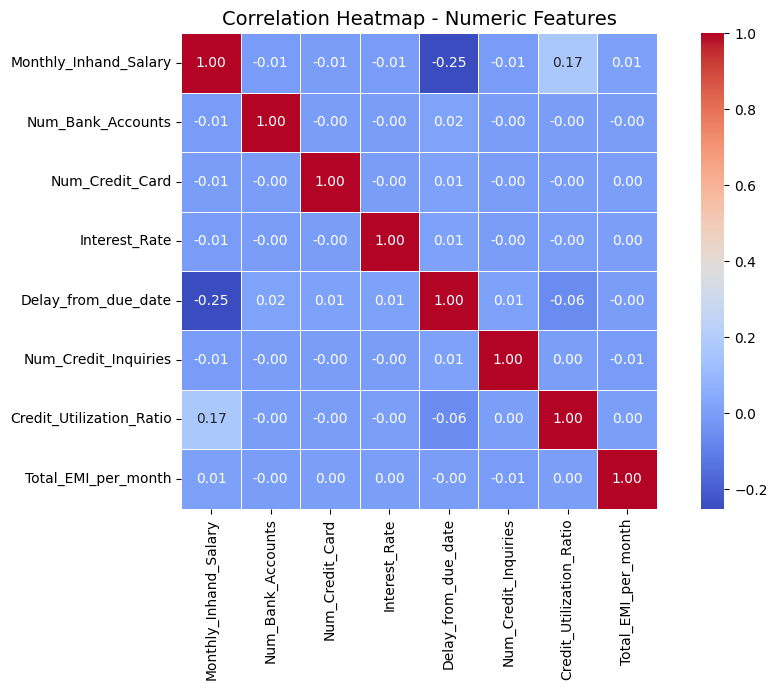

In [23]:
# Correlation Heatmap
plt.figure(figsize=(10,7))
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Observations
# Monthly_Inhand_Salary vs Delay_from_due_date  → -0.25 (negative) 
#   ✅ Higher salary = fewer payment delays (makes sense!)

# Credit_Utilization_Ratio vs Monthly_Inhand_Salary → 0.17 (weak positive)

# Everything else → near 0 (no multicollinearity) ✅

In [ ]:
# EDA Summary — Key Findings:
# Dirty values (/, -, NM, !@9#%8) : Replace with NaN → impute
# Extreme outliers in numeric cols : Cap with IQR method
# Many cols stored as str (Age, Income) : Convert to numeric
# Class imbalance (53/29/18%) : Use class weights in model
# 8 columns with nulls : Impute with median/mode
# Name, SSN, ID cols : Drop — not useful for ML       